In [9]:
import boto3
import pandas as pd
import awswrangler as wr

In [2]:
comprehend_client = boto3.client('comprehend')

In [3]:
df = pd.read_csv('sample.csv')
df.head()

,textID,text,Time of Tweet,Age of User,Country,Population -2020,Land Area (Km²),Density (P/Km²)
0,910d626cd8,"Come on bell, RING. I want to go outside.",noon,60-70,Moldova,4033963,32850.0,123
1,8560ce3f2e,Hey,morning,0-20,Bosnia and Herzegovina,3280819,51000.0,64
2,eca4006095,"I started X-Slimmer at eight this morning, it`...",morning,46-60,Ukraine,43733762,579320.0,75
3,5b34c6a158,"no, i do better with people i don`t know yo...",noon,60-70,Libya,6871292,1759540.0,4
4,4349a49444,the end when they sing this is me and when th...,noon,60-70,Uruguay,3473730,175020.0,20


In [7]:
sentiments = []

for txt in df['text']:
    response = comprehend_client.detect_sentiment(
        Text = txt,
        LanguageCode='en'
    )
    sentiments.append(response['Sentiment'])

In [8]:
df['sentiment']=sentiments
display(df)

,textID,text,Time of Tweet,Age of User,Country,Population -2020,Land Area (Km²),Density (P/Km²),sentiment
0,910d626cd8,"Come on bell, RING. I want to go outside.",noon,60-70,Moldova,4033963,32850.0,123,POSITIVE
1,8560ce3f2e,Hey,morning,0-20,Bosnia and Herzegovina,3280819,51000.0,64,NEUTRAL
2,eca4006095,"I started X-Slimmer at eight this morning, it`...",morning,46-60,Ukraine,43733762,579320.0,75,NEGATIVE
3,5b34c6a158,"no, i do better with people i don`t know yo...",noon,60-70,Libya,6871292,1759540.0,4,NEGATIVE
4,4349a49444,the end when they sing this is me and when th...,noon,60-70,Uruguay,3473730,175020.0,20,POSITIVE
...,...,...,...,...,...,...,...,...,...
270,488ad3f353,"Had a nice concert yesterday. Nice location, n...",night,70-100,United Kingdom,67886011,241930.0,281,MIXED
271,a77df4a95a,I`m still up! Thank you all for praying (: AHA...,night,70-100,Algeria,43851044,2381740.0,18,POSITIVE
272,2f561da8bc,is new to twitter and has no friends here... o...,morning,0-20,Papua New Guinea,8947024,452860.0,20,NEUTRAL
273,7a02ca882d,Dads should ask their 22 year old sons before ...,morning,46-60,Burundi,11890784,25680.0,463,NEUTRAL


In [12]:
from dotenv import load_dotenv
load_dotenv('../../../../.env')

wr.s3.to_csv(
    df=df,
    path="s3://techcatalyst-raw/MELISSA/SENTIMENT/OUTPUT.csv"
)

{'paths': ['s3://techcatalyst-raw/MELISSA/SENTIMENT/OUTPUT.csv'],
 'partitions_values': {}}

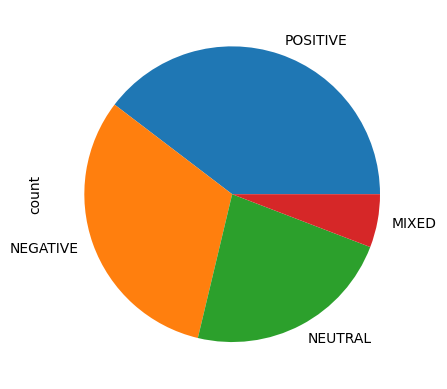

In [22]:
import matplotlib.pyplot as plt
df['sentiment'].value_counts().plot.pie()
plt.savefig("piechart_sentiment.jpg")

s3_client = boto3.client('s3')

s3_client.upload_file(
    Filename="piechart_sentiment.jpg",
    Bucket= 'techcatalyst-raw',
    Key="MELISSA/SENTIMENT/piechart_sentiment.jpg"
)